# Midterm Solutions

## Question 1

In [1]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import niceplots
plt.style.use(niceplots.get_style())
colors = niceplots.get_colors_list()


In [2]:
def redlich_kister_poly(x, coeffs):
    result = 0.0
    for i in range(0, len(coeffs)):
        result += (coeffs[i]) * ((1 - 2*x)**(i+1) - (2*x*i*(1-x))/(1-2*x)**(1-i))  # Higher-order terms

    result += (8.3145 * 298.15 / 96485.3321) * np.log(x/(1-x))

    return result

def rk_excess(x, coeffs):
    result = 0.0
    for i in range(0, len(coeffs)):
        result += (coeffs[i] * x * (1-x) * (1-2*x)**i)  # Higher-order terms

    return result

def loss_function(func, coeffs, x, h):
    predictions = func(x, coeffs)
    return jnp.sum((predictions - h) ** 2)
    

def legendre_poly_recurrence(x, n):
    P = [jnp.ones_like(x), x]  # P_0(x) = 1, P_1(x) = x
    for i in range(1, n):
        P_next = ((2 * i + 1) * x * P[i] - i * P[i - 1]) / (i + 1)
        P.append(P_next)
    return P

def leg_excess(x, coeffs):
    t = 1 - 2 * x
    Pn_values = legendre_poly_recurrence(t,len(coeffs))
    result = 0.0
    for i in range(0, len(coeffs)):
        result += (coeffs[i] * x * (1-x) * Pn_values[i])  # Higher-order terms

    return result


def legendre_derivative_poly_recurrence(x, n):
    """
    Compute the Legendre polynomials derivatives up to degree n 
    using (x^2-1)/n P'n(x) = xP_n(x) - P_(n-1)(x),
    and return all n functions in a list
    """
    Pn_values = legendre_poly_recurrence(x,n)
    Pn_derivatives = [0.0]
    for i in range(1, n+1):
        Pn_derivative_next = (x*Pn_values[i] - Pn_values[i-1])/((x**2-1)/i)
        Pn_derivatives.append(Pn_derivative_next)
    return Pn_derivatives


# Expansion function using Legendre polynomials
def legendre_poly(x, coeffs):
    t = 1 - 2 * x
    Pn_values = legendre_poly_recurrence(t, len(coeffs))  # Compute Legendre polynomials up to degree len(coeffs) - 1
    Pn_der_values = legendre_derivative_poly_recurrence(t, len(coeffs))
    # print(len(Pn_values), len(Pn_der_values), len(coeffs))
    # print(Pn_values)
    
    # Compute the polynomial expansion by summing over coefficients
    term_1 = -x * sum(coeffs[i] * Pn_values[i] for i in range(len(coeffs)))
    term_2 = (1-x) * sum(coeffs[i] * Pn_values[i] for i in range(len(coeffs)))
    term_3 = x * (1-x) * sum(coeffs[i] * Pn_der_values[i] for i in range(len(coeffs))) * -2
    result = (8.3145 * 298.15 / 96485.3321) * np.log(x/(1-x)) + term_1 + term_2 + term_3

    return result

In [3]:
import pandas as pd

In [4]:
df2 = pd.read_csv("ocv.csv")
data_x = df2["x"].to_numpy()
data_ocv = df2["voltage_V"].to_numpy()

Text(0.5, 0, 'SOC')

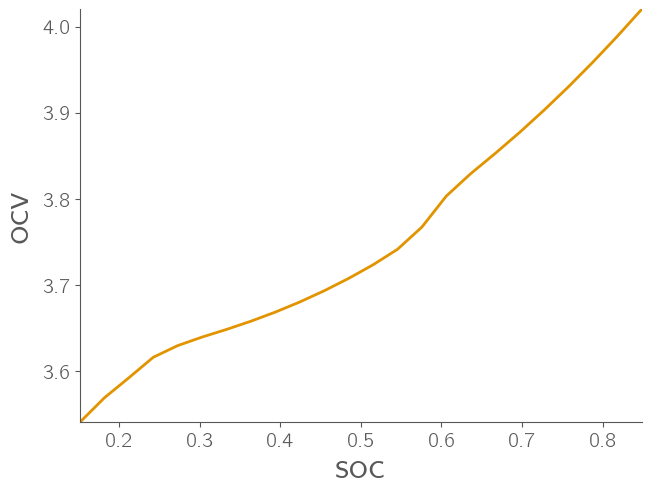

In [5]:
plt.plot(1-data_x, data_ocv)
plt.ylabel("OCV")
plt.xlabel("SOC")


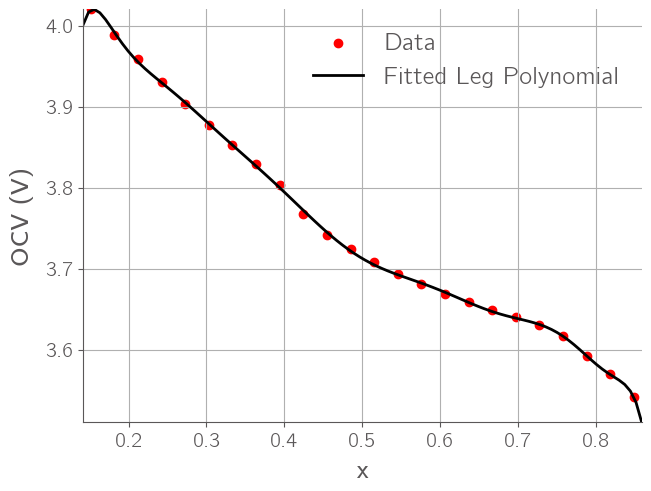

Optimized coefficients Legendre: [-1.24587362e-01  2.56264022e+01  1.44832153e-01  2.20877866e+01
  2.31565477e-02  1.21701403e+01 -4.99618295e-02  4.83634962e+00
 -4.72017202e-02  1.29630333e+00 -1.60411976e-02  1.84482366e-01]


In [6]:
import jax.numpy as jnp
from scipy.optimize import minimize

N = 12
x_data = data_x
h_data = -data_ocv

N_max = 12  # Order of the polynomial
initial_guess_leg = jnp.ones(N_max) * 0.1

result_leg = minimize(lambda c: loss_function(legendre_poly, c, x_data, h_data), initial_guess_leg, method='CG')

leg_optimized_coeffs = result_leg.x

x_fit = jnp.linspace(min(x_data)-0.01, max(x_data)+0.01, 100)

h_fit_leg = legendre_poly(x_fit, leg_optimized_coeffs)

plt.scatter(x_data, -h_data, label='Data', color='red')
plt.plot(x_fit, -h_fit_leg, label='Fitted Leg Polynomial', color='black')

plt.xlabel('x')
plt.ylabel('OCV (V)')
plt.legend()
plt.grid(True)
plt.show()

print("Optimized coefficients Legendre:", leg_optimized_coeffs)

In [7]:
print(1-x_data)

[0.15151515 0.18181818 0.21212121 0.24242424 0.27272727 0.3030303
 0.33333333 0.36363636 0.39393939 0.42424242 0.45454545 0.48484848
 0.51515152 0.54545455 0.57575758 0.60606061 0.63636364 0.66666667
 0.6969697  0.72727273 0.75757576 0.78787879 0.81818182 0.84848485]


In [8]:
df_pulse = pd.read_csv("pulse.csv")
time = df_pulse["time_s"].to_numpy()
voltage = df_pulse["voltage_V"].to_numpy()
current = df_pulse["current_A"].to_numpy()

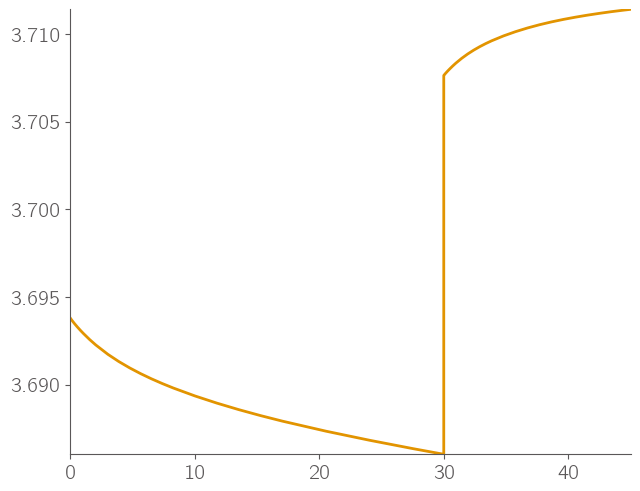

In [9]:
plt.plot(time, voltage)

In [10]:
idx = np.where(current == 0)
R0_cutoff = voltage[idx[0][0]-1]

R0 = (voltage[idx[0][0]] - R0_cutoff) / current[0]
V_0 = current[0] * R0 + voltage[0]
print(R0)

0.008642256497284072


In [11]:
disc_time = time[idx[0][0]-1]
capacity_max = 5
initial_soc =  0.505
print(disc_time)

del_soc = current[0] * disc_time / 3600 / capacity_max
print(current[0], del_soc)
final_soc = initial_soc - del_soc
print(final_soc)

30.0
2.5 0.004166666666666667
0.5008333333333334


In [12]:
print(voltage[-1], -legendre_poly(1-final_soc, leg_optimized_coeffs), -legendre_poly(final_soc, leg_optimized_coeffs))

3.7114102137104887 3.712945402532134 3.712001696957115


0.6479128534523017 0.6262803060214689


10.813826643711204
0.008642256497284072 0.0021227041190689635 5094.363621649843


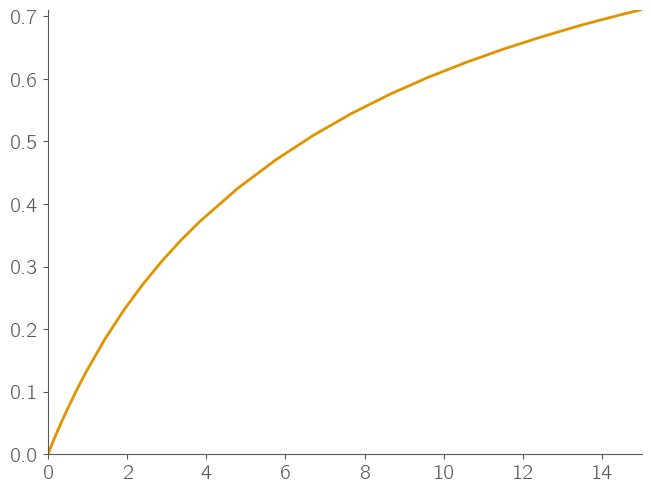

In [13]:
R1 = (-legendre_poly(1-final_soc, leg_optimized_coeffs) - voltage[idx[0][0]])/ current[0]

plt.plot(time[idx[0]] - time[idx[0][0]], (voltage[idx[0]] - voltage[idx[0][0]]) / (current[0] * R1))

v_norm = (voltage[idx[0]] - voltage[idx[0][0]]) / (current[0] * R1)
time_norm = time[idx[0]] - time[idx[0][0]]

idx1 = np.where(v_norm - 0.632 >0)[0][0]
idx2 = np.where(v_norm - 0.632 < 0)[0][-1]
print(v_norm[idx1], v_norm[idx2])

phi = (0.632 - v_norm[idx2]) / (v_norm[idx1]-v_norm[idx2])

tau = phi * (time_norm[idx1]-time_norm[idx2]) + time_norm[idx2]
print(tau)
C1 = tau / R1

print(R0, R1, C1)

0.662408989058656 0.598486624050542
5.3033114215760255
0.008642256497284072 0.0015086285904109431 3515.3194466050977


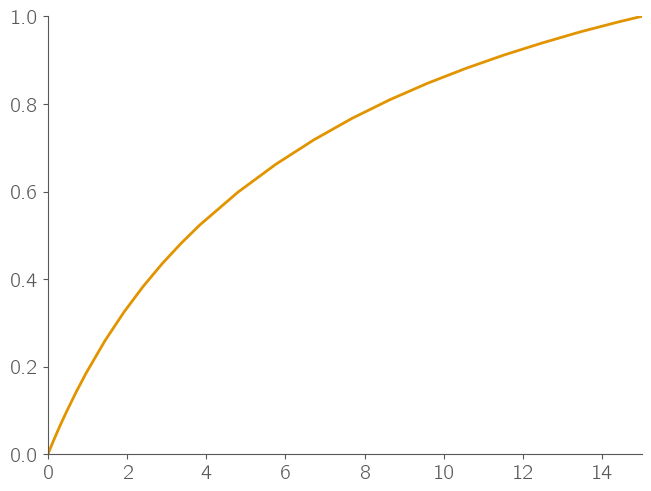

In [14]:
R1 = (voltage[-1] - voltage[idx[0][0]])/ current[0]

plt.plot(time[idx[0]] - time[idx[0][0]], (voltage[idx[0]] - voltage[idx[0][0]]) / (current[0] * R1))

v_norm = (voltage[idx[0]] - voltage[idx[0][0]]) / (current[0] * R1)
time_norm = time[idx[0]] - time[idx[0][0]]

idx1 = np.where(v_norm - 0.632 >0)[0][0]
idx2 = np.where(v_norm - 0.632 < 0)[0][-1]
print(v_norm[idx1], v_norm[idx2])

phi = (0.632 - v_norm[idx2]) / (v_norm[idx1]-v_norm[idx2])

tau = phi * (time_norm[idx1]-time_norm[idx2]) + time_norm[idx2]
print(tau)
C1 = tau / R1

print(R0, R1, C1)

## Question 2

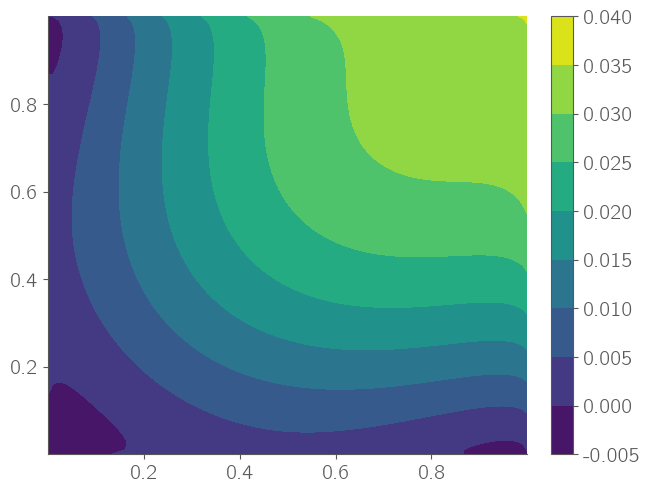

In [15]:
kB_T = 0.0257

omega_a = 3.4 * kB_T
omega_b = 1.4 * kB_T
omega_d = 1 * kB_T

def sample_bounded_pairs(a, n):
    lo = max(0.0, a - 1.0)
    hi = min(1.0, a)

    if hi < lo:
        return []

    if n == 1:
        x1 = 0.5 * (lo + hi)
        return [(x1, a - x1)]

    step = (hi - lo) / (n - 1)
    xs = [lo + i * step for i in range(n)]
    return [(x1, a - x1) for x1 in xs]

def g(x1, x2):
    
    sum  = omega_a * x1 * (1- x1) + kB_T * (x1*np.log(x1) + (1-x1)*np.log(1-x1))
    sum += omega_a * x2 * (1- x2) + kB_T * (x2*np.log(x2) + (1-x2)*np.log(1-x2))
    sum += omega_b * x1 * x2
    sum += omega_d * ( x1 * x2 *(1-x1) + x2 * x1 * (1-x2))
    
    return sum

N = 100
x1, x2 = np.meshgrid(np.linspace(1e-6, 1-1e-6, N), np.linspace(1e-6, 1-1e-6, N))
plt.contourf(x1, x2, g(x1, x2))
plt.colorbar()


/var/folders/vm/pqk04tfx5xz4k8hgkz8zw4dw0000gn/T/ipykernel_97592/2190756236.py:28: RuntimeWarning: divide by zero encountered in log
  sum  = omega_a * x1 * (1- x1) + kB_T * (x1*np.log(x1) + (1-x1)*np.log(1-x1))
/var/folders/vm/pqk04tfx5xz4k8hgkz8zw4dw0000gn/T/ipykernel_97592/2190756236.py:28: RuntimeWarning: invalid value encountered in multiply
  sum  = omega_a * x1 * (1- x1) + kB_T * (x1*np.log(x1) + (1-x1)*np.log(1-x1))
/var/folders/vm/pqk04tfx5xz4k8hgkz8zw4dw0000gn/T/ipykernel_97592/2190756236.py:29: RuntimeWarning: divide by zero encountered in log
  sum += omega_a * x2 * (1- x2) + kB_T * (x2*np.log(x2) + (1-x2)*np.log(1-x2))
/var/folders/vm/pqk04tfx5xz4k8hgkz8zw4dw0000gn/T/ipykernel_97592/2190756236.py:29: RuntimeWarning: invalid value encountered in multiply
  sum += omega_a * x2 * (1- x2) + kB_T * (x2*np.log(x2) + (1-x2)*np.log(1-x2))


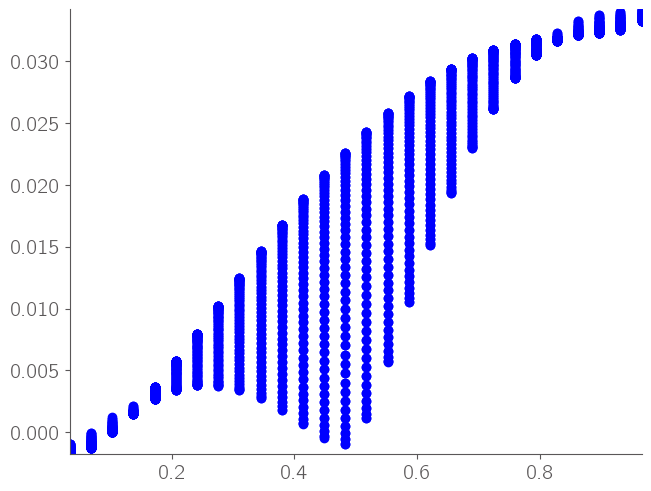

In [16]:
kB_T = 0.0257

omega_a = 3.4 * kB_T
omega_b = 1.4 * kB_T
omega_d = 1 * kB_T

def sample_bounded_pairs(a, n):
    lo = max(0.0, a - 1.0)
    hi = min(1.0, a)

    if hi < lo:
        return []

    if n == 1:
        x1 = 0.5 * (lo + hi)
        return [(x1, a - x1)]

    step = (hi - lo) / (n - 1)
    xs = [lo + i * step for i in range(n)]
    return [(x1, a - x1) for x1 in xs]

def g(x):
    vals = np.array(sample_bounded_pairs(2*x, 100))
    # print(vals)
    
    x1, x2 = vals[:, 0], vals[:, 1]
    
    sum  = omega_a * x1 * (1- x1) + kB_T * (x1*np.log(x1) + (1-x1)*np.log(1-x1))
    sum += omega_a * x2 * (1- x2) + kB_T * (x2*np.log(x2) + (1-x2)*np.log(1-x2))
    sum += omega_b * x1 * x2
    sum += omega_d * ( x1 * x2 *(1-x1) + x2 * x1 * (1-x2))
    
    plt.scatter(np.ones_like(x1)*x, sum, color="blue")
  # return sum

x = np.linspace(0,1, 30)

for x_val in x:
  # plt.scatter(x, g(x_val))
  g(x_val)



/var/folders/vm/pqk04tfx5xz4k8hgkz8zw4dw0000gn/T/ipykernel_97592/3786466482.py:11: RuntimeWarning: divide by zero encountered in log
  sum  = omega_a * x1 * (1- x1) + kB_T * (x1*np.log(x1) + (1-x1)*np.log(1-x1))
/var/folders/vm/pqk04tfx5xz4k8hgkz8zw4dw0000gn/T/ipykernel_97592/3786466482.py:11: RuntimeWarning: invalid value encountered in multiply
  sum  = omega_a * x1 * (1- x1) + kB_T * (x1*np.log(x1) + (1-x1)*np.log(1-x1))
/var/folders/vm/pqk04tfx5xz4k8hgkz8zw4dw0000gn/T/ipykernel_97592/3786466482.py:12: RuntimeWarning: divide by zero encountered in log
  sum += omega_a * x2 * (1- x2) + kB_T * (x2*np.log(x2) + (1-x2)*np.log(1-x2))
/var/folders/vm/pqk04tfx5xz4k8hgkz8zw4dw0000gn/T/ipykernel_97592/3786466482.py:12: RuntimeWarning: invalid value encountered in multiply
  sum += omega_a * x2 * (1- x2) + kB_T * (x2*np.log(x2) + (1-x2)*np.log(1-x2))
/var/folders/vm/pqk04tfx5xz4k8hgkz8zw4dw0000gn/T/ipykernel_97592/3786466482.py:12: RuntimeWarning: invalid value encountered in log
  sum += ome

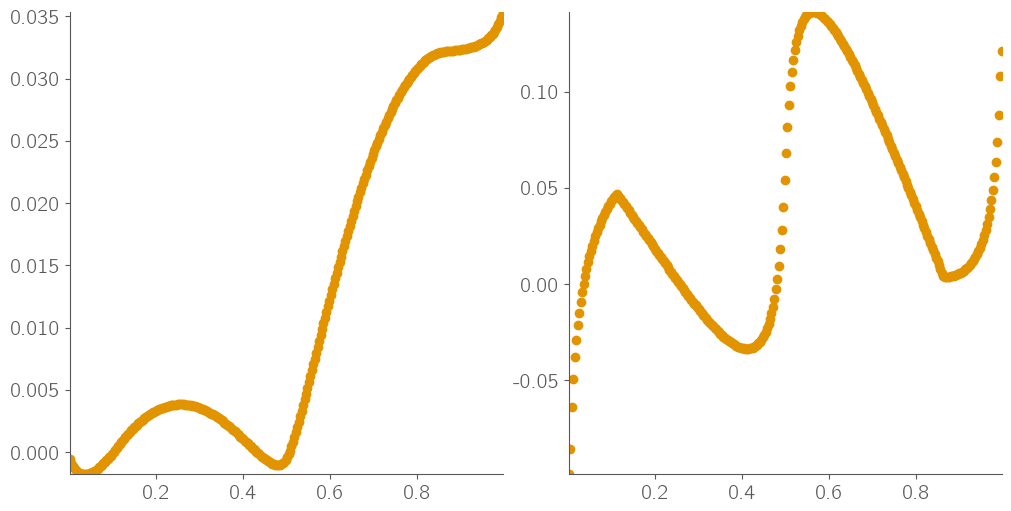

In [17]:
kB_T = 0.0257

omega_a = 3.4 * kB_T
omega_b = 1.4 * kB_T
omega_d = 1 * kB_T

def g_min(x):
    vals = np.array(sample_bounded_pairs(2*x, 1000))
    x1, x2 = vals[:, 0], vals[:, 1]
    
    sum  = omega_a * x1 * (1- x1) + kB_T * (x1*np.log(x1) + (1-x1)*np.log(1-x1))
    sum += omega_a * x2 * (1- x2) + kB_T * (x2*np.log(x2) + (1-x2)*np.log(1-x2))
    sum += omega_b * x1 * x2
    sum += omega_d * ( x1 * x2 *(1-x1) + x2 * x1 * (1-x2))

    mask = ~np.isnan(sum)
    sum = sum[mask]

    if len(sum)==0:
        return

    idx = np.argmin(sum)
    # print(idx, len(x1), x1[idx], x2[idx], x)
    
    return min(sum)

x = np.linspace(0,1, 300)
g_min_vals = []

for x_val in x:
  g_min_vals.append(g_min(x_val))

fig, ax = plt.subplots(1,2,figsize=(10, 5))

g_min_vals = np.array(g_min_vals[1:-1])
x = x[1:-1]
# print(g_min_vals)
ax[0].scatter(x, g_min_vals)
ax[1].scatter(x, np.gradient(g_min_vals, x[0]))



In [18]:
import numpy as np

def find_common_tangent(x, G, slope_tol=1e-3, above_tol=1e-6, min_points_between=3):
    """
    Find the phase-coexistence (tie-line) by applying the common-tangent method
    to discrete (x, G) samples of molar Gibbs free energy.

    Parameters
    ----------
    x : array_like, shape (n,)
        Composition (or order parameter) samples, assumed in (0,1] or similar.
    G : array_like, shape (n,)
        Gibbs free energy values at x.
    slope_tol : float
        Tolerance on matching the secant slope to the endpoint derivatives.
    above_tol : float
        Tolerance for requiring G(x) to lie above the candidate common-tangent line
        on (x1, x2). Lower is stricter.
    min_points_between : int
        Require at least this many interior sample points strictly between x1 and x2.

    Returns
    -------
    result : dict or None
        If found:
            {
              "x1": x1, "x2": x2,
              "mu": m,                # chemical potential = slope of tie-line
              "b": b,                 # intercept so that line is L(x) = m*x + b
              "indices": (i, j),      # indices of x1, x2 in the sorted arrays
            }
        If no valid common tangent is found, returns None.

    Notes
    -----
    - Derivatives at sample points are estimated by centered finite differences
      (one-sided at the ends).
    - The algorithm scans all pairs (i, j) with i < j, tests tangent conditions
      at endpoints, and checks that the curve stays above the line in-between.
    - If multiple candidates satisfy the conditions, the one with the smallest
      total mismatch in endpoint slopes is returned; tie is broken by larger span.
    """
    x = np.asarray(x).astype(float)
    G = np.asarray(G).astype(float)
    if x.ndim != 1 or G.ndim != 1 or x.size != G.size or x.size < 4:
        raise ValueError("x and G must be 1D arrays of the same length (>=4).")

    # sort by x (stable)
    order = np.argsort(x)
    x = x[order]
    G = G[order]
    n = x.size

    # estimate dG/dx at sample points (finite differences)
    dG = np.empty_like(G)
    # centered for interior
    dG[1:-1] = (G[2:] - G[:-2]) / (x[2:] - x[:-2])
    # one-sided at ends
    dG[0]  = (G[1] - G[0]) / (x[1] - x[0])
    dG[-1] = (G[-1] - G[-2]) / (x[-1] - x[-2])

    best = None
    best_score = np.inf

    for i in range(0, n - 1):
        for j in range(i + 30, n):
            # Need interior points to test "above the line" condition
            if j - i - 1 < min_points_between:
                continue

            xi, xj = x[i], x[j]
            Gi, Gj = G[i], G[j]
            m = (Gj - Gi) / (xj - xi)  # candidate slope (chemical potential)
            # endpoint tangency: slopes should match dG/dx at i and j
            mis_i = abs(m - dG[i])
            mis_j = abs(m - dG[j])
            if mis_i > slope_tol or mis_j > slope_tol:
                continue

            b = Gi - m * xi
            # Check that G(x) >= L(x) between xi and xj (within a small tolerance)
            k = slice(i + 1, j)  # strictly interior points
            L_mid = m * x[k] + b
            gap = G[k] - L_mid
            if np.min(gap) < -above_tol:
                continue

            # Score: sum of mismatches; prefer wider tie-lines on tie
            score = mis_i + mis_j
            span = xj - xi
            choose = (score < best_score) or (np.isclose(score, best_score) and best and span > (best["x2"] - best["x1"]))
            if score < best_score or (best is not None and np.isclose(score, best_score) and span > (best["x2"] - best["x1"])):
                best_score = score
                # print(score, xi)
                best = {"x1": xi, "x2": xj, "mu": m, "b": b, "indices": (i, j), "Gi": Gi, "Gj": Gj, "dGi": dG[i], "dGj": dG[j]}

    return best


x1=0.036789, x2=0.481605, g1=-0.001792, g2=-0.001044, dg1=0.000226, dg2=0.002736
Miscibility gap = 0.4448160535117057
x1=0.501672, x2=0.986622, g1=-0.000431, g2=0.034350, dg1=0.068199, dg2=0.073836
Miscibility gap = 0.48494983277591974


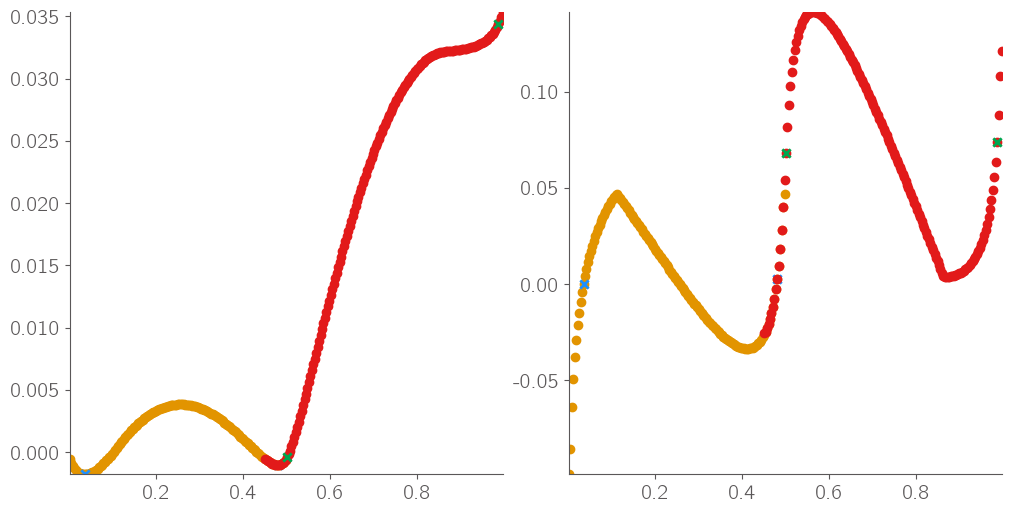

In [19]:
# x, G are your sampled arrays

idx = np.where(x < 0.5)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].scatter(x[idx], g_min_vals[idx])
ax[1].scatter(x[idx], np.gradient(g_min_vals[idx], x[0]))

res = find_common_tangent(x[idx], g_min_vals[idx], slope_tol=2e-2, above_tol=1e-6)

if res is None:
    print("No common tangent (two-phase region) found with current tolerances.")
else:
    x1, x2, g1, g2, dg1, dg2, mu, b = res["x1"], res["x2"], res["Gi"], res["Gj"], res["dGi"], res["dGj"], res["mu"], res["b"]
    print(f"x1={x1:.6f}, x2={x2:.6f}, g1={g1:.6f}, g2={g2:.6f}, dg1={dg1:.6f}, dg2={dg2:.6f}")
    print(f"Miscibility gap = {x2-x1}")
    ax[0].scatter([x1, x2], [g1, g2], marker="x")
    ax[1].scatter([x1, x2], [dg1, dg2], marker="x")

idx = np.where(x > 0.45)

ax[0].scatter(x[idx], g_min_vals[idx])
ax[1].scatter(x[idx], np.gradient(g_min_vals[idx], x[0]))

res = find_common_tangent(x[idx], g_min_vals[idx], slope_tol=1e-2, above_tol=1e-6)

if res is None:
    print("No common tangent (two-phase region) found with current tolerances.")
else:
    x1, x2, g1, g2, dg1, dg2, mu, b = res["x1"], res["x2"], res["Gi"], res["Gj"], res["dGi"], res["dGj"], res["mu"], res["b"]
    print(f"x1={x1:.6f}, x2={x2:.6f}, g1={g1:.6f}, g2={g2:.6f}, dg1={dg1:.6f}, dg2={dg2:.6f}")
    print(f"Miscibility gap = {x2-x1}")
    ax[0].scatter([x1, x2], [g1, g2], marker="x")
    ax[1].scatter([x1, x2], [dg1, dg2], marker="x")



/var/folders/vm/pqk04tfx5xz4k8hgkz8zw4dw0000gn/T/ipykernel_97592/1267754607.py:11: RuntimeWarning: divide by zero encountered in log
  sum  = omega_a * x1 * (1- x1) + kB_T * (x1*np.log(x1) + (1-x1)*np.log(1-x1))
/var/folders/vm/pqk04tfx5xz4k8hgkz8zw4dw0000gn/T/ipykernel_97592/1267754607.py:11: RuntimeWarning: invalid value encountered in multiply
  sum  = omega_a * x1 * (1- x1) + kB_T * (x1*np.log(x1) + (1-x1)*np.log(1-x1))
/var/folders/vm/pqk04tfx5xz4k8hgkz8zw4dw0000gn/T/ipykernel_97592/1267754607.py:12: RuntimeWarning: divide by zero encountered in log
  sum += omega_a * x2 * (1- x2) + kB_T * (x2*np.log(x2) + (1-x2)*np.log(1-x2))
/var/folders/vm/pqk04tfx5xz4k8hgkz8zw4dw0000gn/T/ipykernel_97592/1267754607.py:12: RuntimeWarning: invalid value encountered in multiply
  sum += omega_a * x2 * (1- x2) + kB_T * (x2*np.log(x2) + (1-x2)*np.log(1-x2))
/var/folders/vm/pqk04tfx5xz4k8hgkz8zw4dw0000gn/T/ipykernel_97592/1267754607.py:12: RuntimeWarning: invalid value encountered in log
  sum += ome

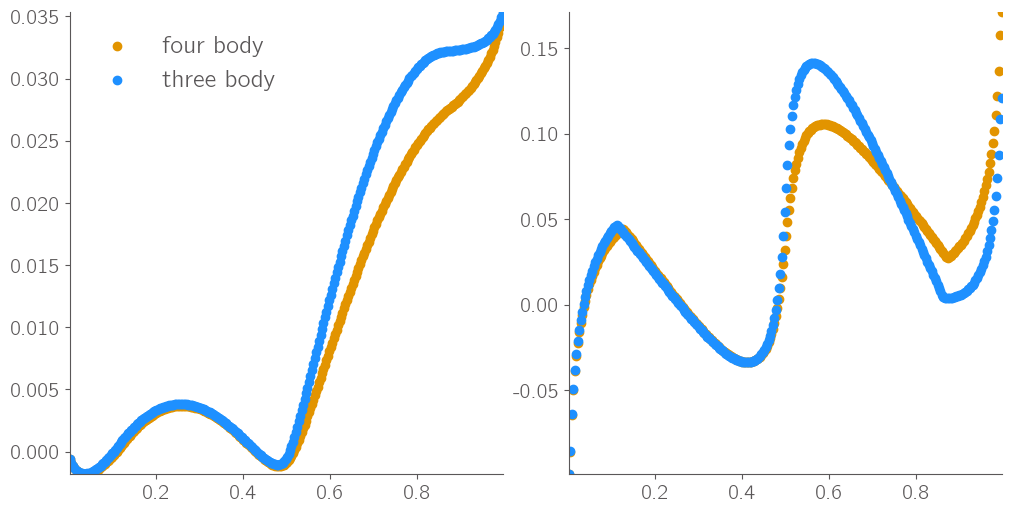

In [20]:
kB_T = 0.0257

omega_a = 3.4 * kB_T
omega_b = 1.4 * kB_T
omega_c = 1 * kB_T

def g_min_mod(x):
    vals = np.array(sample_bounded_pairs(2*x, 1000))
    x1, x2 = vals[:, 0], vals[:, 1]

    sum  = omega_a * x1 * (1- x1) + kB_T * (x1*np.log(x1) + (1-x1)*np.log(1-x1))
    sum += omega_a * x2 * (1- x2) + kB_T * (x2*np.log(x2) + (1-x2)*np.log(1-x2))
    sum += omega_b * x1 * x2
    sum += omega_c * x1 * x2 * (1-x1) * (1-x2)

    mask = ~np.isnan(sum)
    sum = sum[mask]

    if len(sum)==0:
        return

    idx = np.argmin(sum)
    # print(idx, len(x1), x1[idx], x2[idx], x)

    return min(sum)

x = np.linspace(0,1, 300)
g1_min_vals = []

for x_val in x:
  g1_min_vals.append(g_min_mod(x_val))

fig, ax = plt.subplots(1,2,figsize=(10, 5))

g1_min_vals = np.array(g1_min_vals[1:-1])
x = x[1:-1]
# print(g_min_vals)
ax[0].scatter(x, g1_min_vals, label="four body")
ax[1].scatter(x, np.gradient(g1_min_vals, x[0]))

ax[0].scatter(x, g_min_vals, label="three body")
ax[1].scatter(x, np.gradient(g_min_vals, x[0]))

ax[0].legend()


## Question 3

In [21]:
import numpy as np
import matplotlib.pyplot as plt

mu0_a = 0.04
mu0_b = 0.05
omega = 0.1
kB = 8.617e-5
T = 298

x = np.linspace(0.01,0.99,100)

# Define the mu_eq function for integration
def mu_eq_func(x):
  return mu0_b - mu0_a + omega * (1-2*x) + kB*T * np.log (x/(1-x))

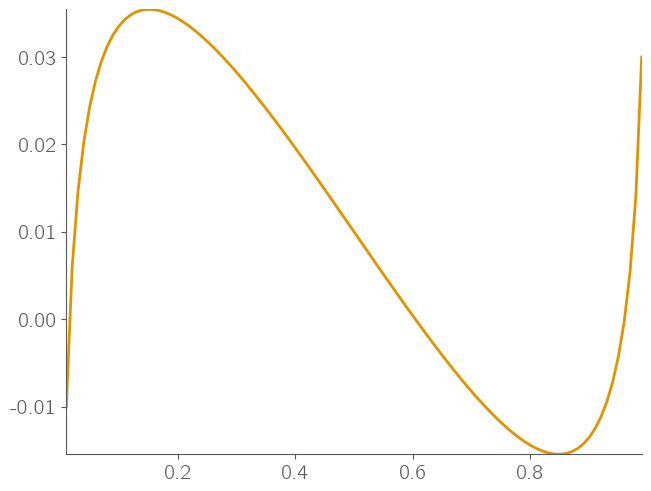

In [22]:
plt.plot(x,mu_eq_func(x))


In [23]:
def mu_noneq_func(x):
  return mu_eq_func(x) + kB * T * np.log (1 + 1/(1-x))

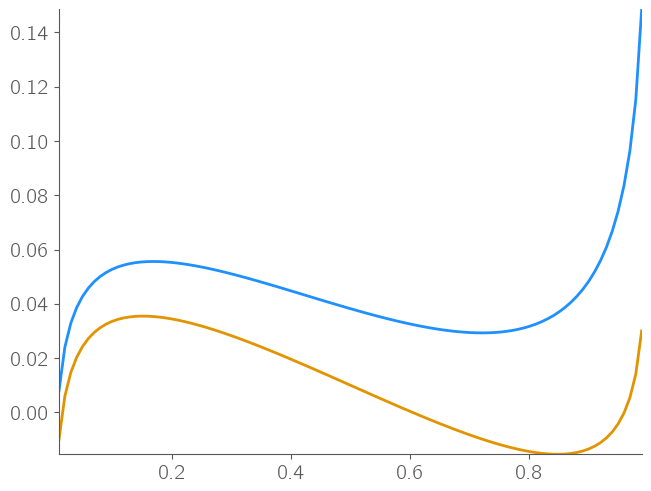

In [24]:
plt.plot(x,mu_eq_func(x))
plt.plot(x,mu_noneq_func(x))


In [25]:
from scipy.optimize import fsolve
from scipy.integrate import quad

# Define a function that returns the difference between mu_eq and the target value
def mu_eq_difference(x, target_mu):
  return mu_eq_func(x) - target_mu

# Target value for mu_eq
target_mu = 0.01

def mu_eq_difference(x, target_mu=0.01):
  return mu_eq_func(x) - target_mu

# Provide initial guesses for the roots based on the plot
# Looking at the plot of mu_eq, there might be roots around 0.1, 0.5, and 0.9
initial_guesses = [0.05, 0.48, 0.95]

# Find the roots using fsolve
roots = [fsolve(mu_eq_difference, guess, args=(target_mu,))[0] for guess in initial_guesses]

print(f"The roots for mu_eq = {target_mu} are: {roots}")

# Sort the roots to ensure integration is done in increasing order
sorted_roots = sorted(roots)
print("Miscibility gap:", roots[-1]-roots[0])
# Calculate the area between the first two roots
area_between_first_two_roots, _ = quad(mu_eq_difference, sorted_roots[0], sorted_roots[1])

# Calculate the area between the second two roots
area_between_second_two_roots, _ = quad(mu_eq_difference, sorted_roots[1], sorted_roots[2])

print(f"Area between the first two roots: {area_between_first_two_roots}")
print(f"Area between the second two roots: {area_between_second_two_roots}")

The roots for mu_eq = 0.01 are: [np.float64(0.023944213426086006), np.float64(0.5), np.float64(0.976055786573914)]
Miscibility gap: 0.952111573147828
Area between the first two roots: 0.007765912769208766
Area between the second two roots: -0.007765912769208762


In [26]:
# Define a function that returns the difference between mu_eq and the target value
def mu_noneq_difference(x, target_mu=0.0418):
  return mu_noneq_func(x) - target_mu

# Target value for mu_eq
target_mu = 0.0418

# Provide initial guesses for the roots based on the plot
# Looking at the plot of mu_eq, there might be roots around 0.1, 0.5, and 0.9
initial_guesses = [0.05, 0.48, 0.95]

# Find the roots using fsolve
roots = [fsolve(mu_noneq_difference, guess, args=(target_mu,))[0] for guess in initial_guesses]

print(f"The roots for mu_eq = {target_mu} are: {roots}")

# Sort the roots to ensure integration is done in increasing order
sorted_roots = sorted(roots)
print("Miscibility gap:", roots[-1]-roots[0])


# Calculate the area between the first two roots
area_between_first_two_roots, _ = quad(mu_noneq_difference, sorted_roots[0], sorted_roots[1])

# Calculate the area between the second two roots
area_between_second_two_roots, _ = quad(mu_noneq_difference, sorted_roots[1], sorted_roots[2])

print(f"Area between the first two roots: {area_between_first_two_roots}")
print(f"Area between the second two roots: {area_between_second_two_roots}")

The roots for mu_eq = 0.0418 are: [np.float64(0.047141007462339485), np.float64(0.44475116701711953), np.float64(0.8768594424749852)]
Miscibility gap: 0.8297184350126456
Area between the first two roots: 0.0035145333664686387
Area between the second two roots: -0.0035237005644870732
